# K-means

**Objetivo:** 
1) Rodar K-means em um conjunto 2D simples.  
2) Variar `k` e observar o impacto nas métricas internas (Inércia e *Silhouette*).  
3) Visualizar os agrupamentos resultantes e os centróides.

**Conceitos-chave**
- **Inércia (SSE)**: soma das distâncias quadráticas de cada ponto ao centróide do seu cluster. Tende a diminuir conforme `k` aumenta (curva do "cotovelo").
- **Coeficiente de Silhouette**: mede coesão e separação dos clusters (−1 a 1). Quanto maior, melhor a separação.

Requisitos:
- `numpy`, `matplotlib`, `scikit-learn`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib.colors import ListedColormap
import warnings

np.random.seed(42)
warnings.filterwarnings("ignore")

# Gera dados sintéticos 2D
X, y_true = make_blobs(
    n_samples=700,
    centers=4,              # "verdadeiro" número de grupos (para visualização apenas)
    cluster_std=[1.0, 1.3, 0.9, 1.1],
    random_state=42
)

print(X.shape)

(700, 2)


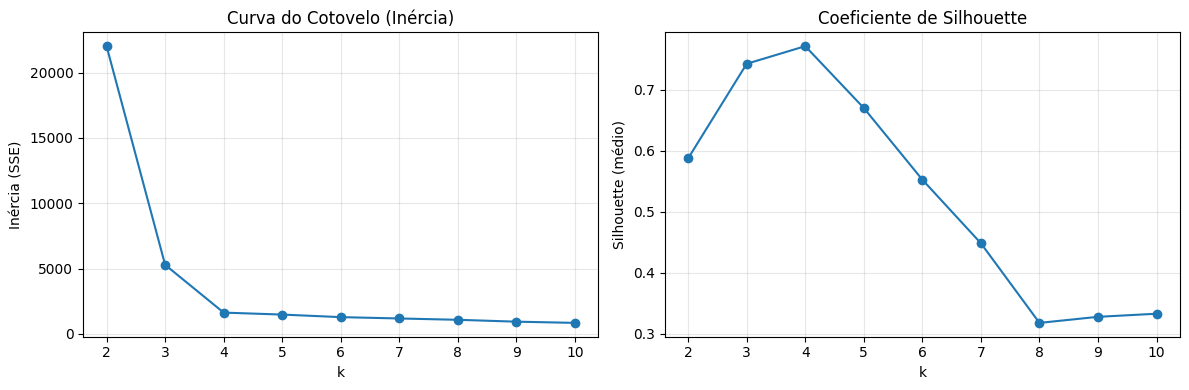

Melhor k por Silhouette: 4 (silhouette=0.771)


In [2]:
# %% [varrer_k_e_metricas]
ks = range(2, 11)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_init="auto", n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels)
    silhouettes.append(sil)

# Plota curvas: Inércia e Silhouette
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(list(ks), inertias, marker="o")
ax[0].set_title("Curva do Cotovelo (Inércia)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inércia (SSE)")
ax[0].grid(True, alpha=0.3)

ax[1].plot(list(ks), silhouettes, marker="o")
ax[1].set_title("Coeficiente de Silhouette")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette (médio)")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = ks[int(np.argmax(silhouettes))]
print(f"Melhor k por Silhouette: {best_k:.0f} (silhouette={max(silhouettes):.3f})")

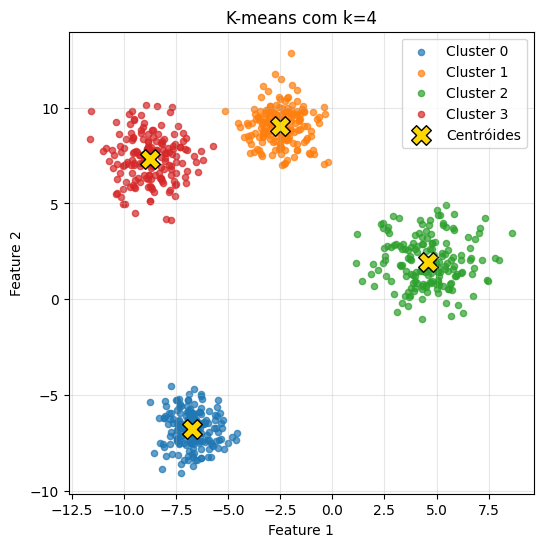

In [3]:
# %% [visualizar_clusters_para_um_k]
def plot_kmeans_result(X, k):
    km = KMeans(n_init="auto", n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    # Geração de uma paleta de cores simples
    max_colors = max(k, 3)
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in range(max_colors)]

    plt.figure(figsize=(6, 6))
    for c in range(k):
        plt.scatter(
            X[labels == c, 0], X[labels == c, 1],
            s=20, alpha=0.7, label=f"Cluster {c}", color=colors[c]
        )
    plt.scatter(centers[:, 0], centers[:, 1], s=200, marker="X",
                edgecolor="k", linewidth=1.0, label="Centróides", color="gold")
    plt.title(f"K-means com k={k}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Experimente com diferentes k:
plot_kmeans_result(X, k=best_k)   # melhor k por silhouette

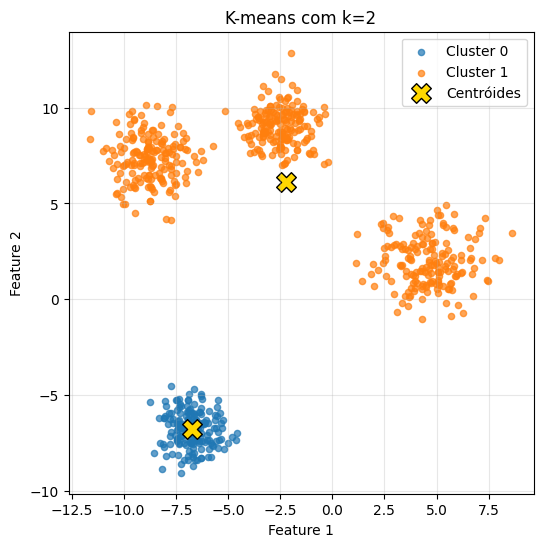

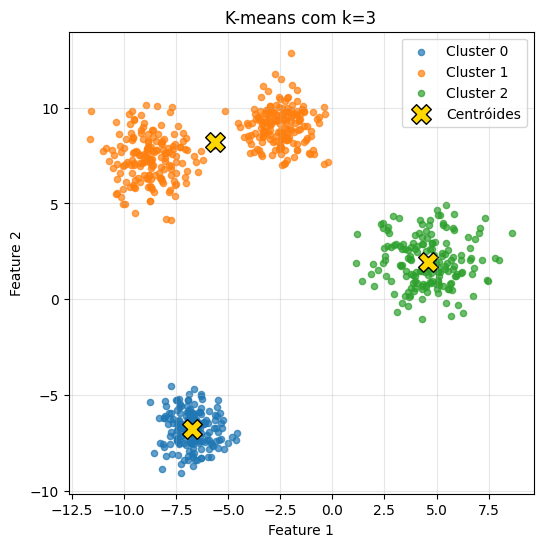

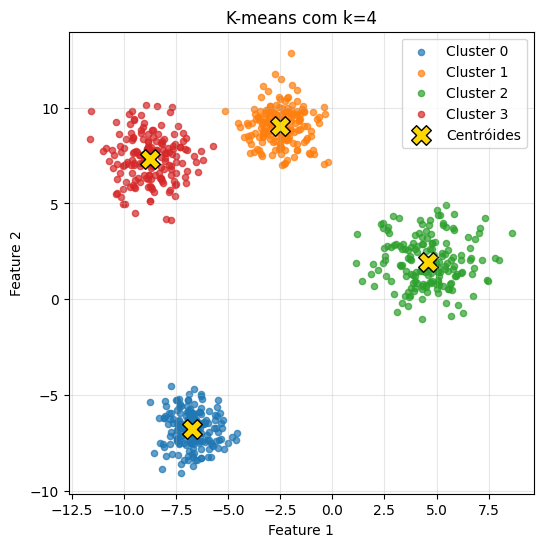

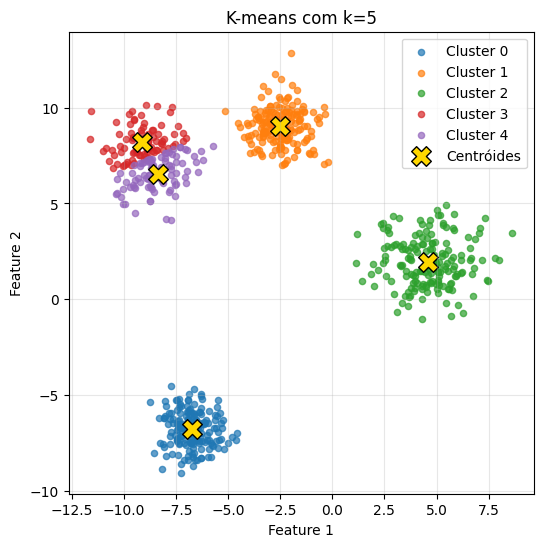

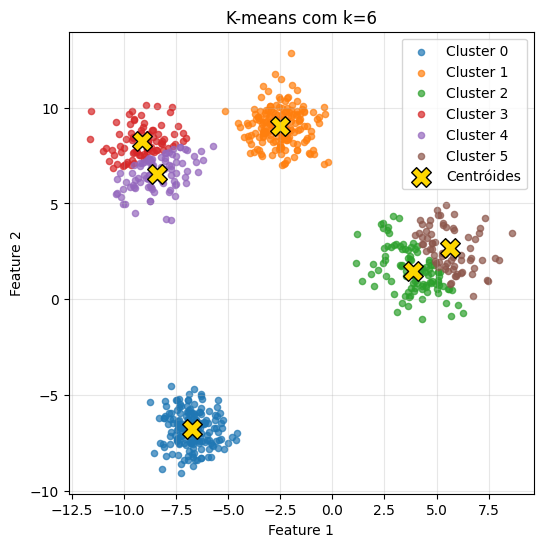

In [4]:
for k in [2, 3, 4, 5, 6]:
    plot_kmeans_result(X, k=k)

## Observações

- A **inércia** sempre diminui com k, então isoladamente não "escolhe" k — observe o "cotovelo".
- O **silhouette** tende a penalizar clusters muito comprimidos/colados; procure o **máximo**.
- Em dados 2D, a visualização ajuda muito: olhe se os centróides fazem sentido e se os clusters estão bem separados.